In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import re
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [3]:
pip install torch


   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.2/113.8 MB 5.3 MB/s eta 0:00:22
   ---------------------------------------- 0.3/113.8 MB 3.5 MB/s eta 0:00:33
   ---------------------------------------- 0.5/113.8 MB 3.7 MB/s eta 0:00:31
   ---------------------------------------- 0.8/113.8 MB 4.5 MB/s eta 0:00:26
   ---------------------------------------- 1.1/113.8 MB 4.8 MB/s eta 0:00:24
   ---------------------------------------- 1.3/113.8 MB 5.0 MB/s eta 0:00:23
    --------------------------------------- 1.6/113.8 MB 5.0 MB/s eta 0:00:23
    --------------------------------------- 1.8/113.8 MB 5.0 MB/s eta 0:00:23
    --------------------------------------- 2.0/113.8 MB 4.8 MB/s eta 0:00:24
    --------------------------------------- 2.2/113.8 MB 4.7 MB/s eta 0:00:24
    --------------------------------------- 2.4/113.8 MB 4.8 MB/s eta 0:00:24
    --------------------------------------- 2.6/113.8 MB 4.8 MB/s eta 

In [6]:
# Загрузка данных
df = pd.read_csv('labeled.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Dataset shape: (14412, 2)
Columns: ['comment', 'toxic']


In [7]:
# Проверка пропусков
print(f"\nMissing values:\n{df.isnull().sum()}")


Missing values:
comment    0
toxic      0
dtype: int64


In [8]:
# Удаляем пустые комментарии
df = df.dropna(subset=['comment'])
print(f"\nAfter dropping nulls: {df.shape}")


After dropping nulls: (14412, 2)


In [9]:
# Анализ распределения меток
df['toxic_binary'] = (df['toxic'] > 0.5).astype(int)
print("Class distribution:")
print(df['toxic_binary'].value_counts())
print(f"\nToxic ratio: {df['toxic_binary'].mean():.2%}")

Class distribution:
toxic_binary
0    9586
1    4826
Name: count, dtype: int64

Toxic ratio: 33.49%


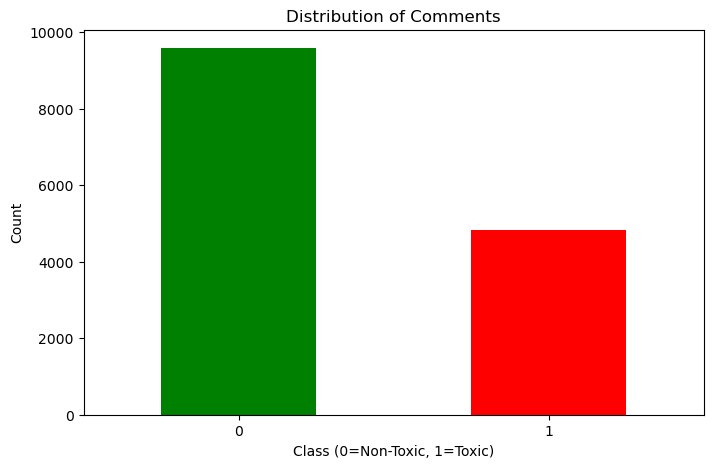

In [10]:
# Визуализация
plt.figure(figsize=(8, 5))
df['toxic_binary'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribution of Comments')
plt.xlabel('Class (0=Non-Toxic, 1=Toxic)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

#  Предобработка текста

In [11]:
def clean_text(text):
    """Очистка текста от лишних символов"""
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    # Удаляем URL
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Удаляем спецсимволы и цифры, оставляем буквы
    text = re.sub(r'[^а-яa-z\s]', '', text)
    # Удаляем лишние пробелы
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Применяем очистку
texts = [clean_text(t) for t in tqdm(df['comment'].tolist(), desc="Cleaning texts")]
labels = df['toxic_binary'].tolist()

Cleaning texts: 100%|█████████████████████████████████████████████████████████| 14412/14412 [00:00<00:00, 19611.79it/s]


In [12]:
print("\nПримеры очищенных текстов:")
for i in range(5):
    print(f"\n{i+1}. Original: {df['comment'].iloc[i][:100]}...")
    print(f"   Cleaned: {texts[i][:100]}...")
    print(f"   Label: {labels[i]}")


Примеры очищенных текстов:

1. Original: Верблюдов-то за что? Дебилы, бл...
...
   Cleaned: верблюдовто за что дебилы бл...
   Label: 1

2. Original: Хохлы, это отдушина затюканого россиянина, мол, вон, а у хохлов еще хуже. Если бы хохлов не было, ки...
   Cleaned: хохлы это отдушина затюканого россиянина мол вон а у хохлов еще хуже если бы хохлов не было кисель и...
   Label: 1

3. Original: Собаке - собачья смерть
...
   Cleaned: собаке собачья смерть...
   Label: 1

4. Original: Страницу обнови, дебил. Это тоже не оскорбление, а доказанный факт - не-дебил про себя во множествен...
   Cleaned: страницу обнови дебил это тоже не оскорбление а доказанный факт недебил про себя во множественном чи...
   Label: 1

5. Original: тебя не убедил 6-страничный пдф в том, что Скрипалей отравила Россия? Анализировать и думать пытаешь...
   Cleaned: тебя не убедил страничный пдф в том что скрипалей отравила россия анализировать и думать пытаешься в...
   Label: 1


In [13]:
def build_vocab(texts, min_freq=2):
    """Построение словаря на основе частотности слов"""
    word_counts = {}
    for text in texts:
        for word in text.split():
            word_counts[word] = word_counts.get(word, 0) + 1
    
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, count in word_counts.items():
        if count >= min_freq:
            vocab[word] = len(vocab)
    
    return vocab, word_counts

vocab, word_counts = build_vocab(texts)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")
print(f"Total unique words: {len(word_counts)}")
print(f"\nTop 20 most common words:")
sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)[:20]
for word, count in sorted_words:
    print(f"  {word}: {count}")


Vocabulary size: 26401
Total unique words: 68729

Top 20 most common words:
  и: 12618
  в: 11939
  не: 10312
  на: 6988
  что: 5589
  а: 4921
  с: 4276
  это: 3933
  я: 3131
  как: 3083
  у: 2883
  по: 2760
  но: 2640
  то: 2332
  так: 2264
  за: 2151
  если: 1895
  все: 1822
  же: 1646
  от: 1480


In [14]:
MAX_LEN = 100
BATCH_SIZE = 64
TEST_SIZE = 0.2
RANDOM_STATE = 42

def encode_texts(texts, vocab, max_len):
    """Токенизация и паддинг текстов"""
    encoded = []
    for text in texts:
        # Токенизация
        tokens = [vocab.get(word, vocab['<UNK>']) for word in text.split()]
        # Обрезка или паддинг
        if len(tokens) > max_len:
            tokens = tokens[:max_len]
        else:
            tokens = tokens + [0] * (max_len - len(tokens))
        encoded.append(tokens)
    return torch.tensor(encoded, dtype=torch.long)

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=labels
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

# Энкодинг
X_train_enc = encode_texts(X_train, vocab, MAX_LEN)
X_test_enc = encode_texts(X_test, vocab, MAX_LEN)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print(f"\nEncoded shapes:")
print(f"X_train: {X_train_enc.shape}")
print(f"X_test: {X_test_enc.shape}")
print(f"y_train: {y_train.shape}")

Train size: 11529
Test size: 2883

Encoded shapes:
X_train: torch.Size([11529, 100])
X_test: torch.Size([2883, 100])
y_train: torch.Size([11529, 1])


In [15]:
class CommentDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = CommentDataset(X_train_enc, y_train)
test_dataset = CommentDataset(X_test_enc, y_test)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#  Определение архитектуры модели (LSTM)

In [18]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, output_dim=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)  
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        lstm_out, (hidden, cell) = self.lstm(embedded)
       
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        hidden = self.dropout(hidden)
        output = self.fc(hidden)
        return self.sigmoid(output)

# Инициализация модели
model = LSTMClassifier(vocab_size).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Подсчет параметров модели
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 2,875,877
Trainable parameters: 2,875,877


# Обучение модели

In [19]:
EPOCHS = 5
train_losses = []
test_accuracies = []

print("Starting training...")
for epoch in range(EPOCHS):
    # Training phase
    model.train()
    total_loss = 0
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}')
    
    for X_batch, y_batch in progress_bar:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # Evaluation phase
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            predicted = (outputs > 0.5).float()
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    
    accuracy = correct / total
    test_accuracies.append(accuracy)
    
    print(f'Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.4f}')

Starting training...


Epoch 1/5: 100%|████████████████████████████████████████████████████████| 181/181 [00:46<00:00,  3.86it/s, loss=0.5488]


Epoch 1/5, Loss: 0.5813, Test Accuracy: 0.7589


Epoch 2/5: 100%|████████████████████████████████████████████████████████| 181/181 [00:45<00:00,  3.96it/s, loss=0.5455]


Epoch 2/5, Loss: 0.4839, Test Accuracy: 0.8037


...

Epoch 3/5, Loss: 0.4068, Test Accuracy: 0.8169


Epoch 4/5: 100%|████████████████████████████████████████████████████████| 181/181 [00:46<00:00,  3.91it/s, loss=0.1036]


Epoch 4/5, Loss: 0.3397, Test Accuracy: 0.8352


Epoch 5/5: 100%|████████████████████████████████████████████████████████| 181/181 [00:41<00:00,  4.35it/s, loss=0.2869]


Epoch 5/5, Loss: 0.2895, Test Accuracy: 0.8411


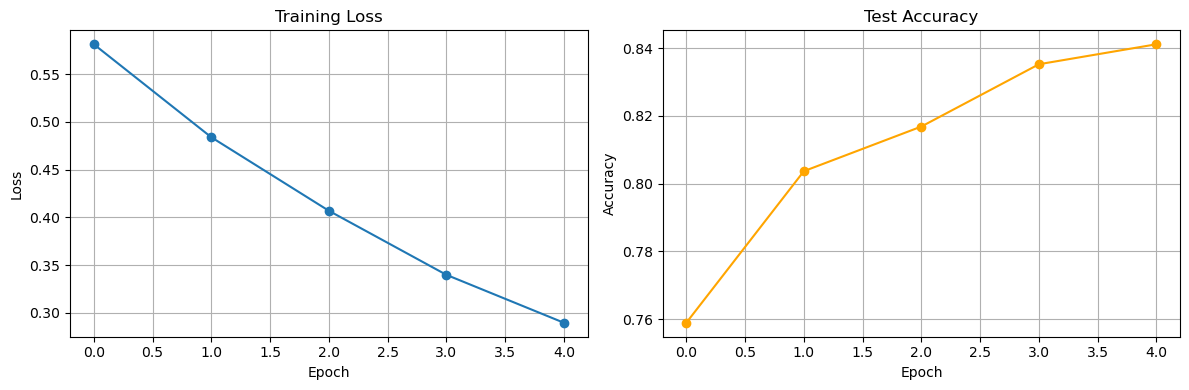

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, marker='o')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(test_accuracies, marker='o', color='orange')
ax2.set_title('Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Оценка модели

Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.89      0.87      0.88      1918
       Toxic       0.75      0.78      0.77       965

    accuracy                           0.84      2883
   macro avg       0.82      0.83      0.82      2883
weighted avg       0.84      0.84      0.84      2883


Accuracy: 0.8411


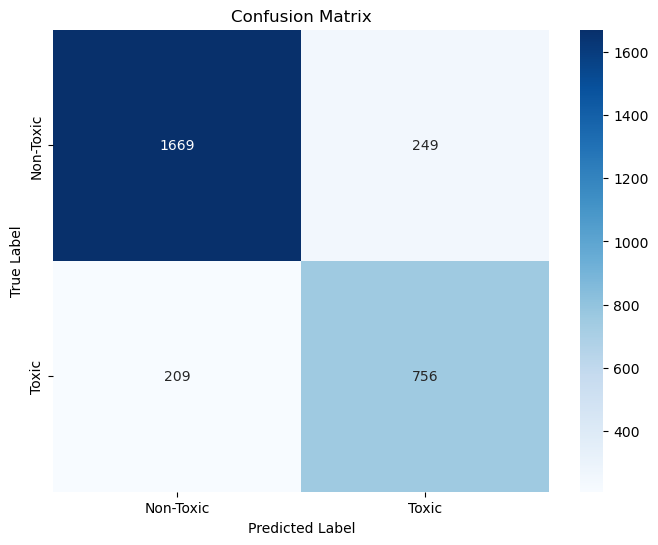

In [21]:
model.eval()
all_preds = []
all_probs = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        probs = model(X_batch).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend((probs > 0.5).astype(int))

y_true = y_test.numpy()
y_pred = np.array(all_preds).flatten()
y_prob = np.array(all_probs).flatten()

# Метрики
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Non-Toxic', 'Toxic']))
print(f"\nAccuracy: {accuracy_score(y_true, y_pred):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Toxic', 'Toxic'],
            yticklabels=['Non-Toxic', 'Toxic'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

#  Тестирование на примерах

In [23]:
def predict_single(text, model, vocab, device, max_len=100):
    """Предсказание для одного текста"""
    cleaned = clean_text(text)
    if not cleaned:
        return 0.0, 0
    
    tokens = [vocab.get(word, vocab['<UNK>']) for word in cleaned.split()]
    if len(tokens) > max_len:
        tokens = tokens[:max_len]
    else:
        tokens = tokens + [0] * (max_len - len(tokens))
    
    tensor = torch.tensor([tokens], dtype=torch.long).to(device)
    
    model.eval()
    with torch.no_grad():
        prob = model(tensor).cpu().item()
    
    return prob, int(prob > 0.5)

# Тестирование
test_comments = [
    "Это отличный комментарий, спасибо за информацию!",
    "Ты дебил и идиот, как ты можешь такое писать?",
    "Сегодня хорошая погода, пойду гулять",
    "Интересная статья, но есть некоторые неточности"
]

print("Testing on examples:")
for comment in test_comments:
    prob, pred = predict_single(comment, model, vocab, device)
    print(f"\nComment: {comment}")
    print(f"Probability: {prob:.3f}")
    print(f"Prediction: {'TOXIC' if pred else 'NON-TOXIC'}")

Testing on examples:

Comment: Это отличный комментарий, спасибо за информацию!
Probability: 0.059
Prediction: NON-TOXIC

Comment: Ты дебил и идиот, как ты можешь такое писать?
Probability: 0.984
Prediction: TOXIC

Comment: Сегодня хорошая погода, пойду гулять
Probability: 0.795
Prediction: TOXIC

Comment: Интересная статья, но есть некоторые неточности
Probability: 0.039
Prediction: NON-TOXIC


In [24]:
# Сохранение модели
MODEL_PATH = 'toxic_lstm_model.pth'
VOCAB_PATH = 'vocab.pkl'

torch.save(model.state_dict(), MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

with open(VOCAB_PATH, 'wb') as f:
    pickle.dump(vocab, f)
print(f"Vocabulary saved to {VOCAB_PATH}")

# Сохранение метаданных
metadata = {
    'max_len': MAX_LEN,
    'vocab_size': vocab_size,
    'embed_dim': 100,
    'hidden_dim': 128,
    'test_accuracy': accuracy_score(y_true, y_pred),
    'train_samples': len(X_train),
    'test_samples': len(X_test)
}

with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)
print("Metadata saved to model_metadata.pkl")

print("\n✅ Training completed successfully!")

Model saved to toxic_lstm_model.pth
Vocabulary saved to vocab.pkl
Metadata saved to model_metadata.pkl

✅ Training completed successfully!
